In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

print(df.head())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

In [4]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
df = df.dropna(subset=["CustomerID"])

print(df.shape)

(406829, 8)


In [6]:
cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")]

print("Cancelled Orders:", cancelled.shape[0])

Cancelled Orders: 8905


In [7]:
df = df[
    ~df["InvoiceNo"].astype(str).str.startswith("C")
]

In [8]:
df = df[df["Quantity"] > 0]

In [9]:
df = df[df["UnitPrice"] > 0]

In [10]:
print(df.shape)

(397884, 8)


In [11]:
df["TotalPrice"] = (
    df["Quantity"] *
    df["UnitPrice"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [12]:
import datetime as dt

snapshot_date = (
    df["InvoiceDate"].max()
    + dt.timedelta(days=1)
)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate":
        lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo":
        "nunique",
    "TotalPrice":
        "sum"
})

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [13]:
print(rfm.shape)
print(rfm.describe())

(4338, 3)
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


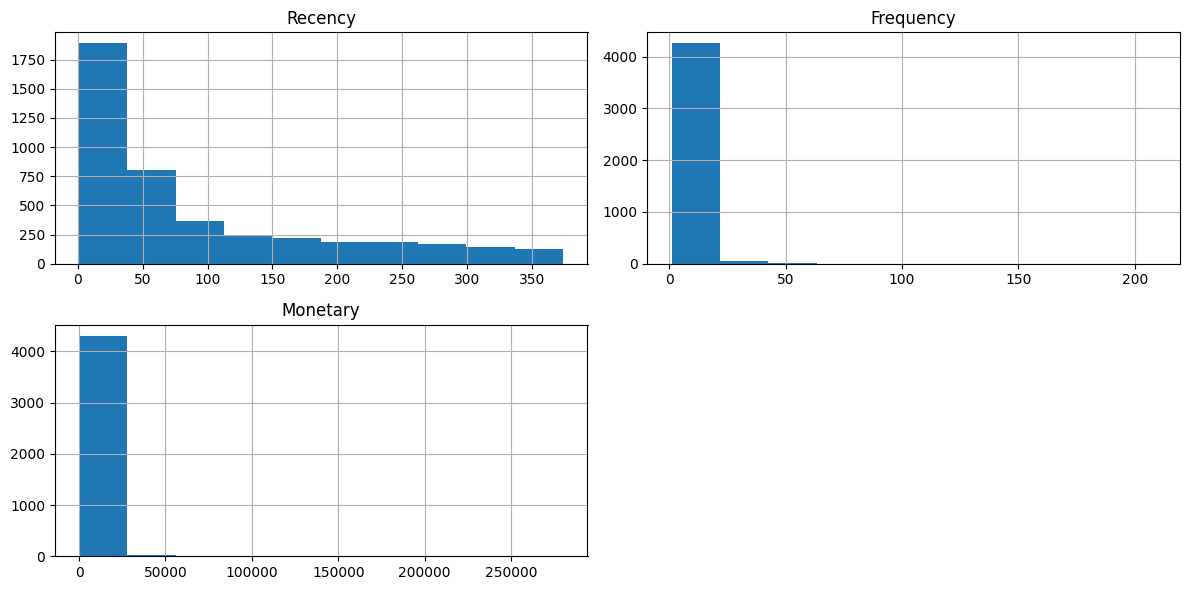

In [14]:
import matplotlib.pyplot as plt

rfm.hist(figsize=(12,6))
plt.tight_layout()
plt.show()

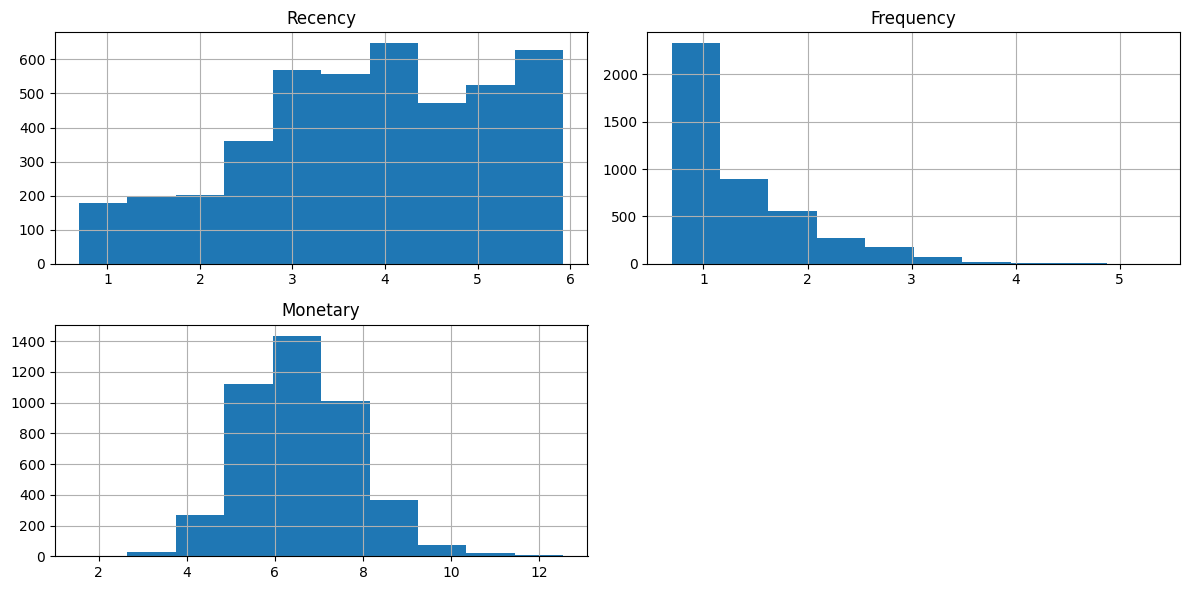

In [15]:
rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

rfm_log.hist(figsize=(12,6))
plt.tight_layout()
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

print(rfm_scaled.shape)

(4338, 3)


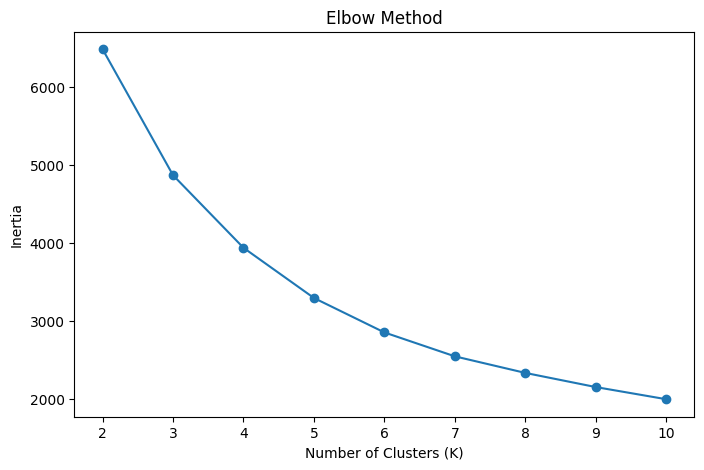

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [18]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(
        f"K = {k}, Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.4329
K = 3, Silhouette Score = 0.3365
K = 4, Silhouette Score = 0.3371
K = 5, Silhouette Score = 0.3161
K = 6, Silhouette Score = 0.3133
K = 7, Silhouette Score = 0.3100
K = 8, Silhouette Score = 0.3008
K = 9, Silhouette Score = 0.2817
K = 10, Silhouette Score = 0.2787


In [19]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["KMeans_Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,KMeans_Cluster
CustomerID,,,,
12346.0,326,1,77183.60,2
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,3


In [20]:
cluster_summary = rfm.groupby(
    "KMeans_Cluster"
).agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
})

print(cluster_summary)

                   Recency  Frequency     Monetary
KMeans_Cluster                                    
0                18.124253   2.148148   551.819534
1                12.131285  13.713687  8074.266872
2                71.084399   4.083546  1802.829005
3               182.496898   1.318238   343.450032


In [21]:
print(
    rfm["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

KMeans_Cluster
0     837
1     716
2    1173
3    1612
Name: count, dtype: int64


In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = rfm["KMeans_Cluster"].values

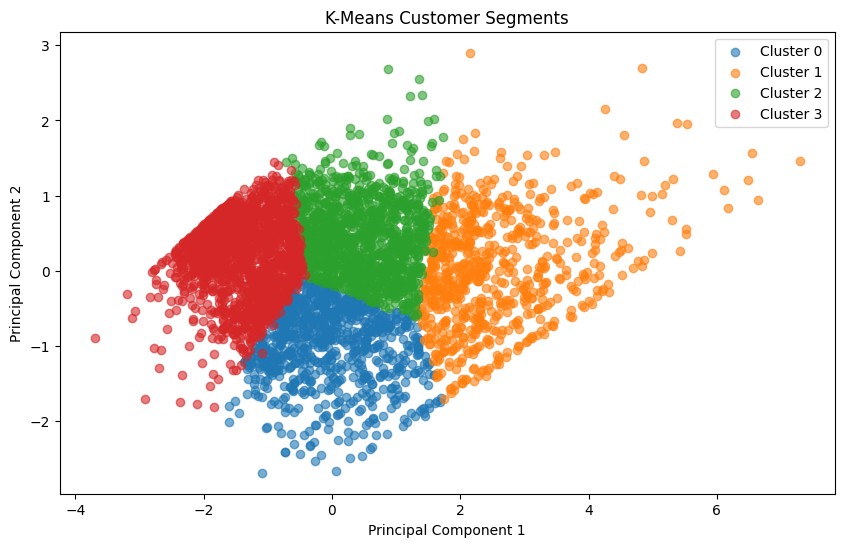

In [23]:


plt.figure(figsize=(10,6))

for cluster in sorted(
    pca_df["Cluster"].unique()
):
    subset = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.title("K-Means Customer Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

In [24]:
cluster_summary = rfm.groupby("KMeans_Cluster").agg({
    "Recency": ["mean", "median"],
    "Frequency": ["mean", "median"],
    "Monetary": ["mean", "median"]
})

print(cluster_summary)

                   Recency         Frequency            Monetary          
                      mean median       mean median         mean    median
KMeans_Cluster                                                            
0                18.124253   17.0   2.148148    2.0   551.819534   471.700
1                12.131285    8.0  13.713687   10.0  8074.266872  3733.870
2                71.084399   56.0   4.083546    4.0  1802.829005  1345.620
3               182.496898  177.0   1.318238    1.0   343.450032   298.255


In [25]:
print(
    rfm["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

KMeans_Cluster
0     837
1     716
2    1173
3    1612
Name: count, dtype: int64


In [26]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

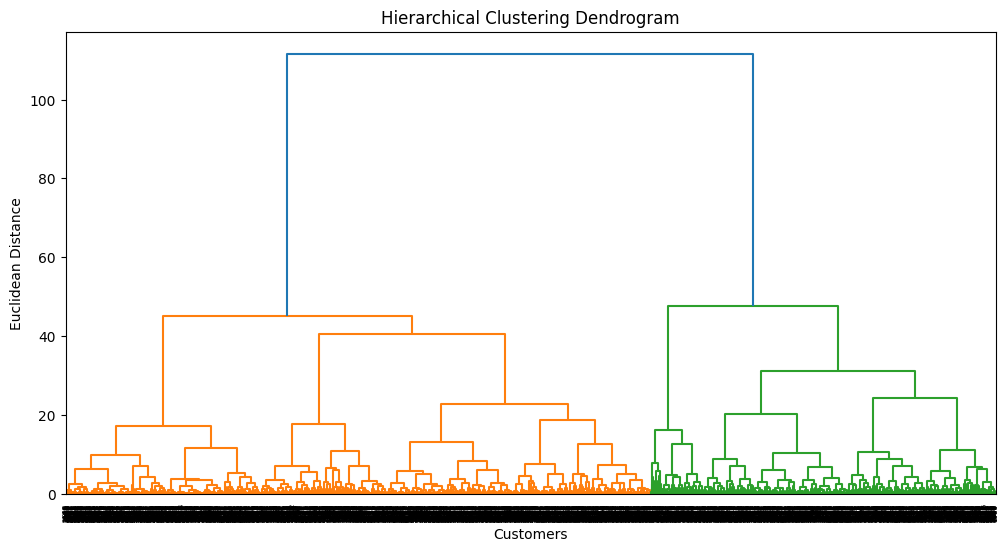

In [27]:
plt.figure(figsize=(12,6))

linked = linkage(
    rfm_scaled,
    method="ward"
)

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [28]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

rfm["Hierarchical_Cluster"] = hierarchical.fit_predict(
    rfm_scaled
)

rfm.head()

,Recency,Frequency,Monetary,KMeans_Cluster,Hierarchical_Cluster
CustomerID,,,,,
12346.0,326,1,77183.60,2,0
12347.0,2,7,4310.00,1,1
12348.0,75,4,1797.24,2,0
12349.0,19,1,1757.55,0,1
12350.0,310,1,334.40,3,3


In [29]:
hierarchical_summary = rfm.groupby(
    "Hierarchical_Cluster"
).agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
})

print(hierarchical_summary)

                         Recency  Frequency      Monetary
Hierarchical_Cluster                                     
0                      79.948352   2.083516    804.527276
1                      23.131965   5.644428   2190.551592
2                      10.586777  24.309917  17458.925620
3                     243.205044   1.269737    256.793739


In [30]:
print(
    rfm["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

Hierarchical_Cluster
0    1820
1    1364
2     242
3     912
Name: count, dtype: int64


In [31]:
pca_df["Hierarchical_Cluster"] = rfm["Hierarchical_Cluster"].values

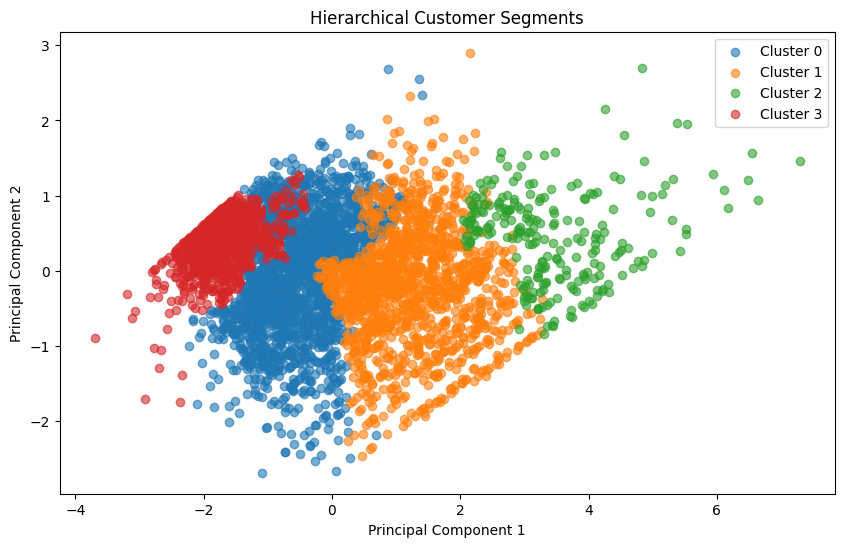

In [32]:
plt.figure(figsize=(10,6))

for cluster in sorted(
    pca_df["Hierarchical_Cluster"].unique()
):
    subset = pca_df[
        pca_df["Hierarchical_Cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.title("Hierarchical Customer Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()